# Bank Churn Prediction using Machine Learning 

#### -> The goal is to develop a machine learning model that predicts whether a customer will exit or not.

## 1. Importing Required Libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings  # For avoid deprecation
warnings.filterwarnings('ignore') 

## 2. Loading the Dataset

In [7]:
# retrive data from xlxs file 

data=pd.read_csv('Bank_Churn.csv')
df=pd.DataFrame(data)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Exploration

In [9]:
# to check shape of dataframe
df.shape

(10000, 13)

In [10]:
# to check information details of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [11]:
# to check missing values
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
# to check duplicates
df.duplicated().sum()

0

In [13]:
# Drop unused features
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df.shape

(10000, 11)

In [15]:
# Summarize numerical features
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [16]:
# Summarize categorical features
df.describe(include=['object'])

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


## 4. Exploratory Data Analysis (EDA)

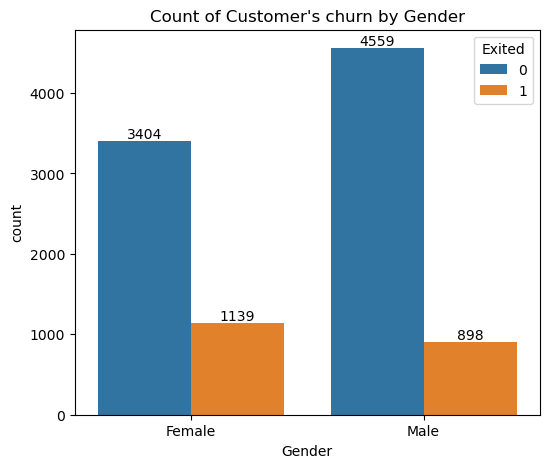

In [18]:
# count of customer who stay(0) and exit(1)
plt.figure(figsize=(6, 5))
ax=sns.countplot(data=df, x='Gender', hue='Exited')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Count of Customer's churn by Gender")
plt.show()

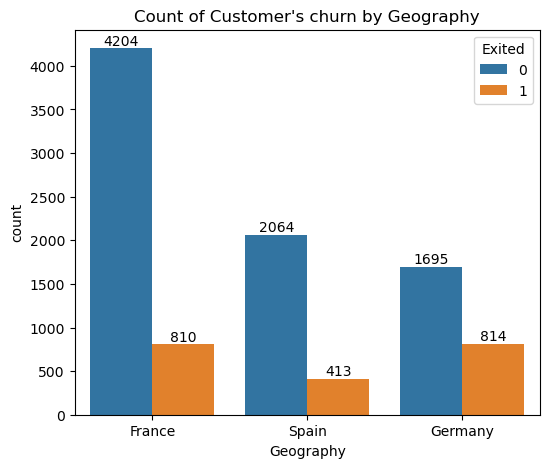

In [19]:
# Count of Customer's churn by Geography
plt.figure(figsize=(6, 5))
ax=sns.countplot(data=df, x='Geography', hue='Exited')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Count of Customer's churn by Geography")
plt.show()

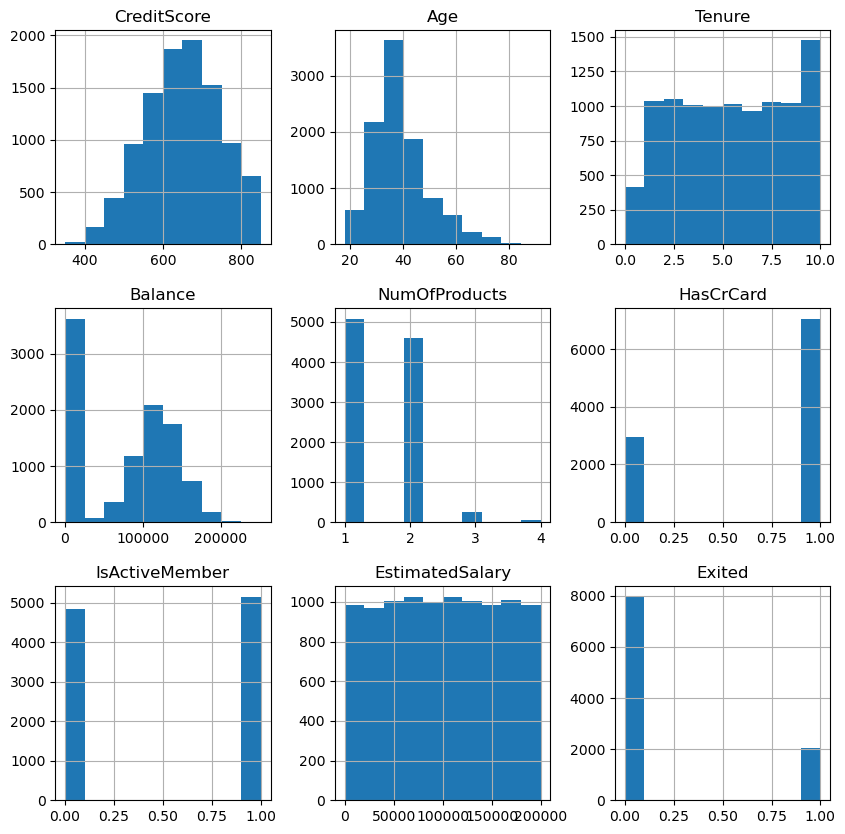

In [20]:
# Plot histogram grid
# Displays continuous numerical data by dividing it into bins
df.hist(figsize=(10,10))
plt.show()

In [21]:
# to check the shape of dataset
df.shape

(10000, 11)

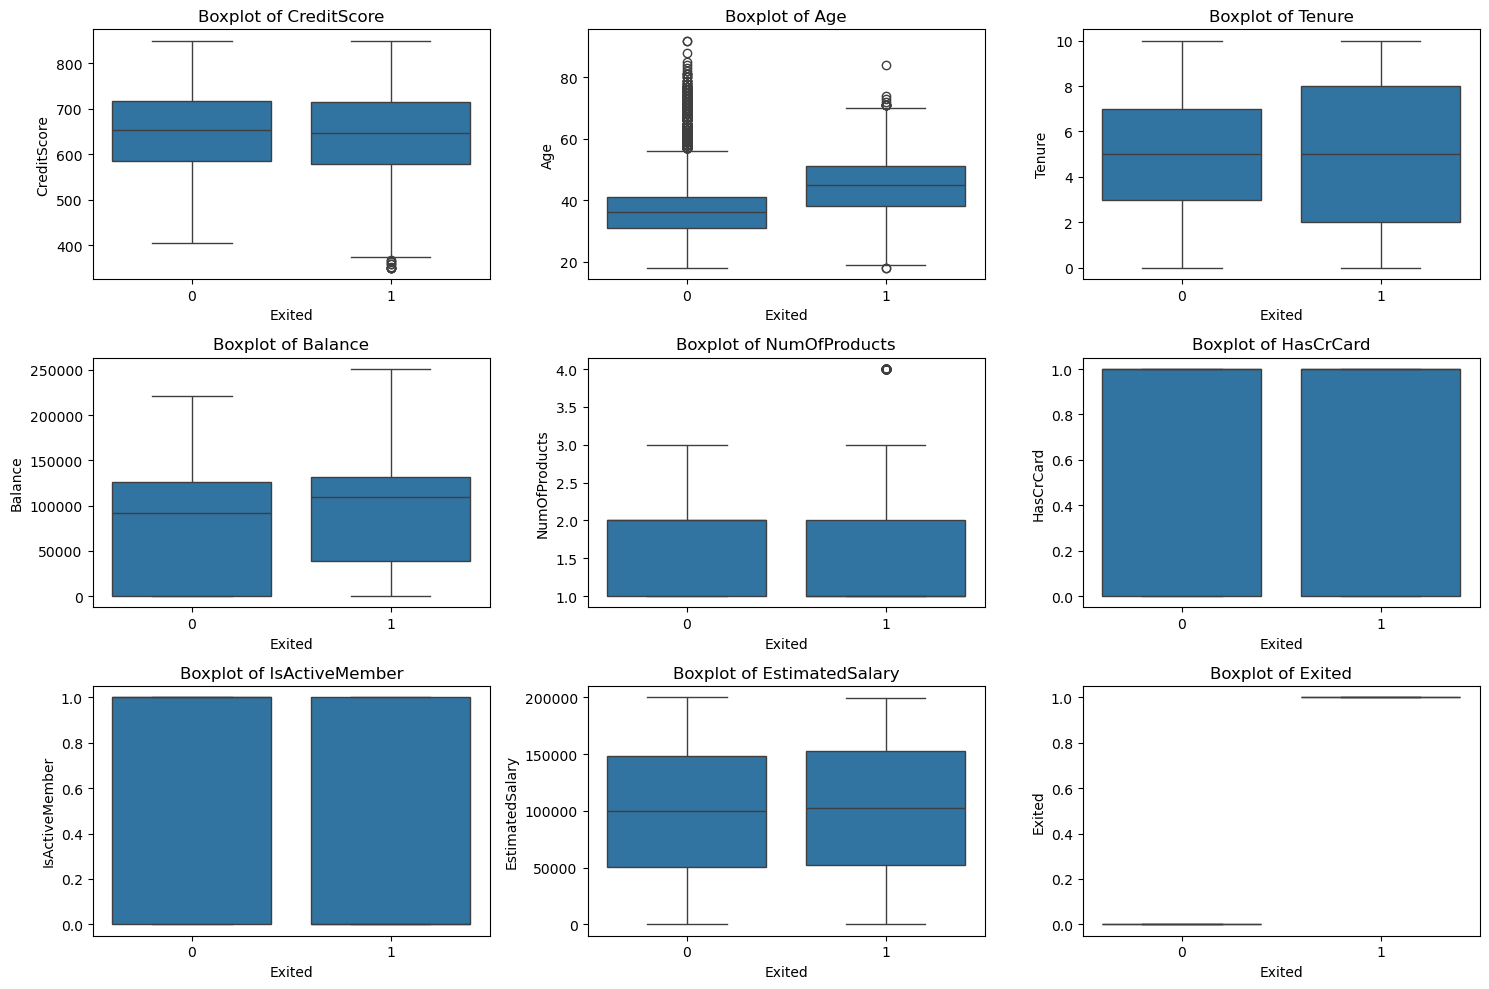

In [22]:
# to check the outliers using boxplot
x=df.select_dtypes(exclude=['object']).columns
plt.figure(figsize=(15, 10))
for i, feature in enumerate(x):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Exited', y=feature, data=df)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

In [23]:
# remove the outliers
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df1 = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]
df1.shape

(9641, 11)

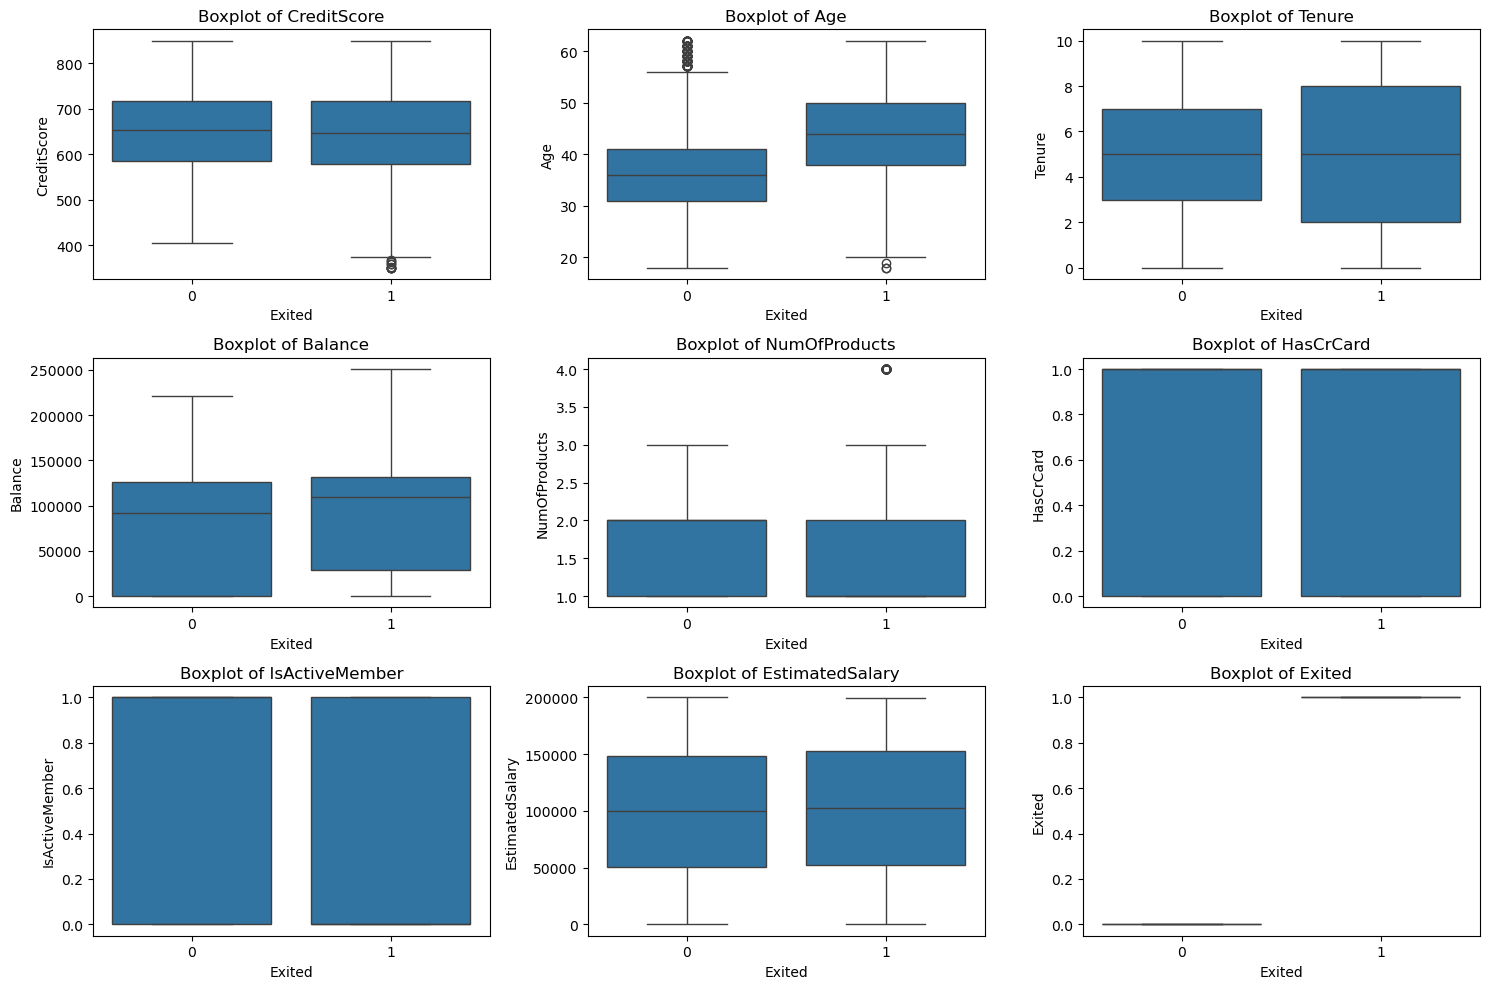

In [24]:
# After removed the outliers of boxplot
plt.figure(figsize=(15, 10))
for i, feature in enumerate(x):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Exited', y=feature, data=df1)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

In [25]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
# convert a object type to int type using label encoder
from sklearn.preprocessing import LabelEncoder
categorical_cols=['Geography', 'Gender']
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()  # Create a LabelEncoder for each column
    df1[col] = label_encoders[col].fit_transform(df1[col])  # Transform the column

In [27]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df1['Geography'].unique()

array([0, 2, 1])

In [29]:
# Correlation analysis is a statistical technique for determining the strength of a link between two variables
corr=df1.corr()
corr

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.009167,-0.003220,-0.015989,0.000749,0.006396,0.011484,-0.002502,0.022432,-0.000493,-0.025456
Geography,0.009167,1.000000,0.003493,0.028397,0.002630,0.067767,0.006425,-0.010900,0.008213,-0.004187,0.034779
Gender,-0.003220,0.003493,1.000000,-0.031014,0.014292,0.010013,-0.022035,0.006411,0.022436,-0.007462,-0.106843
Age,-0.015989,0.028397,-0.031014,1.000000,-0.010406,0.041216,-0.033588,-0.016305,0.017519,-0.004559,0.358888
Tenure,0.000749,0.002630,0.014292,-0.010406,1.000000,-0.013340,0.015460,0.019974,-0.027323,0.009457,-0.013832
Balance,0.006396,0.067767,0.010013,0.041216,-0.013340,1.000000,-0.302469,-0.013464,-0.007328,0.010537,0.116932
NumOfProducts,0.011484,0.006425,-0.022035,-0.033588,0.015460,-0.302469,1.000000,0.002735,0.010453,0.013100,-0.050396
HasCrCard,-0.002502,-0.010900,0.006411,-0.016305,0.019974,-0.013464,0.002735,1.000000,-0.012289,-0.009731,-0.007369
IsActiveMember,0.022432,0.008213,0.022436,0.017519,-0.027323,-0.007328,0.010453,-0.012289,1.000000,-0.010357,-0.144331
EstimatedSalary,-0.000493,-0.004187,-0.007462,-0.004559,0.009457,0.010537,0.013100,-0.009731,-0.010357,1.000000,0.011120


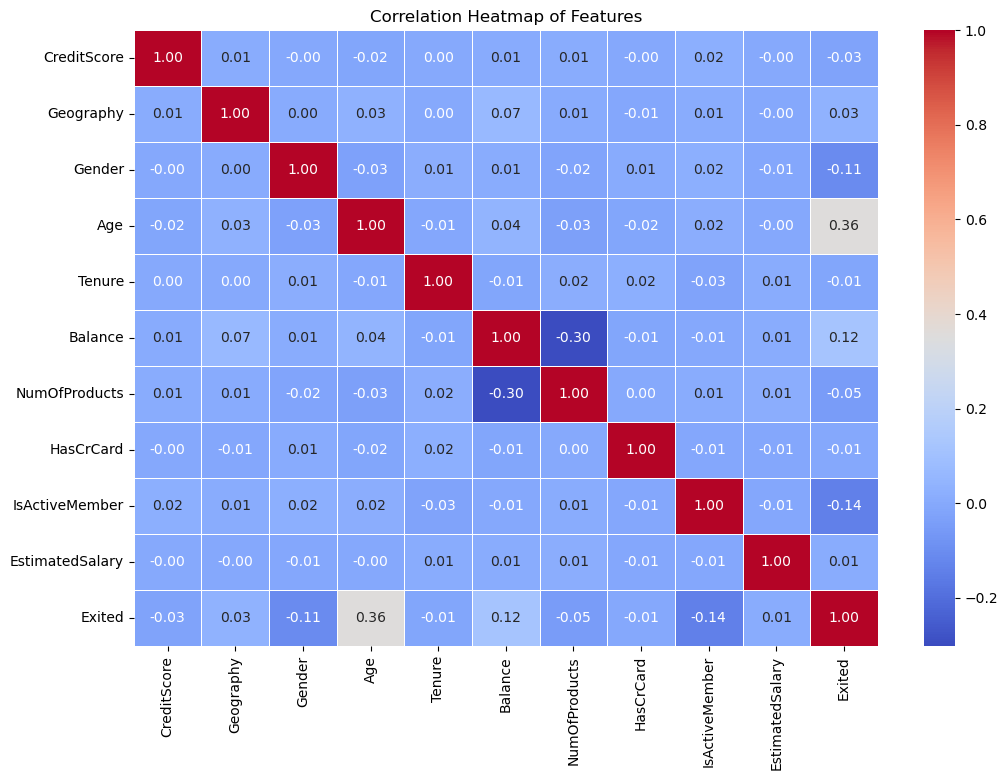

In [30]:
# heat map visualization for correlation
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

In [31]:
# define features and target varibles
X=df1.drop(columns=['Exited']) # Features Variable(Input Variable)
y=df1['Exited']  # Target Variable

In [32]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


## 5. Handle Imbalance using SMOTE

In [34]:
#SMOTE (synthetic minority oversampling technique) is one of the most commonly used oversampling methods to solve the imbalance problem.

from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [35]:
X_resampled.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


## 6. Train-Test Split

In [37]:
# Model Training and Testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X_resampled,y_resampled,test_size=0.3, random_state=42)

In [38]:
X_test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
8807,775,0,0,27,4,152309.370000,1,1,0,104112.000000
1889,604,0,1,53,8,144453.750000,1,1,0,190998.960000
7025,679,0,1,29,3,0.000000,2,1,1,63687.060000
15304,681,1,0,41,4,109481.304757,1,1,0,79940.404294
3996,850,2,1,39,0,141829.670000,1,1,1,92748.160000


## 7. Model Building

In [40]:
# import algorithm libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [41]:
#Logistic Regression

model_lr = LogisticRegression(max_iter=10000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

#Decision Tree

model_dt= DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

#Random Forest

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

#XGBoost classifier

model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb=model_xgb.predict(X_test)

#Support Vector Machine (SVM)

model_svm = SVC(random_state=42)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)

#Naive Bayes

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

#k-Nearest Neighbors (kNN)

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

## 8. Model Evaluation

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

res={}
def evaluate_model(y_test, y_pred):
   return {
        "Accuracy": round(accuracy_score(y_test, y_pred)*100,2),
        "Precision": round(precision_score(y_test, y_pred), 2),
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1-Score": round(f1_score(y_test, y_pred), 2),
        "ROC AUC": round(roc_auc_score(y_test, y_pred),2)
    }

res['Logistic Regression']= evaluate_model(y_test, y_pred_lr)

res['Decision Tree']= evaluate_model(y_test, y_pred_dt)

res['Random Forest']= evaluate_model(y_test, y_pred_rf)

res['XGBoost']= evaluate_model(y_test, y_pred_xgb)

res['Support Vector Machine']= evaluate_model(y_test, y_pred_svm)

res['Naive Bayes']= evaluate_model(y_test, y_pred_nb)

res['K-Nearest Neighbors']= evaluate_model(y_test, y_pred_knn)


res_df=pd.DataFrame(res)
res_df

,Logistic Regression,Decision Tree,Random Forest,XGBoost,Support Vector Machine,Naive Bayes,K-Nearest Neighbors
Accuracy,77.75,79.84,85.33,85.28,57.07,73.26,66.25
Precision,0.77,0.79,0.85,0.85,0.55,0.72,0.63
Recall,0.78,0.80,0.85,0.85,0.76,0.75,0.74
F1-Score,0.77,0.80,0.85,0.85,0.64,0.73,0.68
ROC AUC,0.78,0.80,0.85,0.85,0.57,0.73,0.66


## 9. Visualization of Evaluation Metrics 

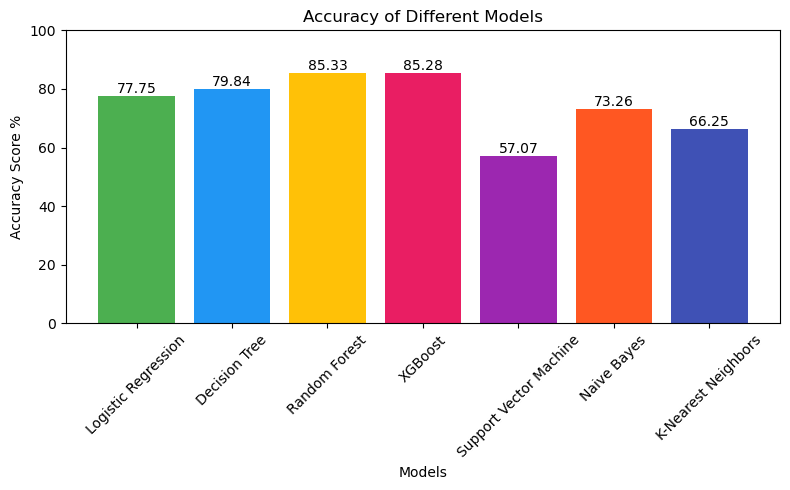

In [45]:
accuracies = res_df.iloc[0]

plt.figure(figsize=(8, 5))
plt.bar(res_df.columns,accuracies , color = ['#4CAF50', '#2196F3', '#FFC107','#E91E63','#9C27B0', '#FF5722', '#3F51B5'] )

plt.title('Accuracy of Different Models')
plt.xlabel('Models')
plt.ylabel('Accuracy Score %')
plt.ylim(0, 100)
plt.xticks(rotation=45)

for i, val in enumerate(accuracies):
    plt.text(i, val,f"{val}",ha='center', va='bottom')
    
plt.tight_layout()
plt.show()


## 10. Confusion Matrix

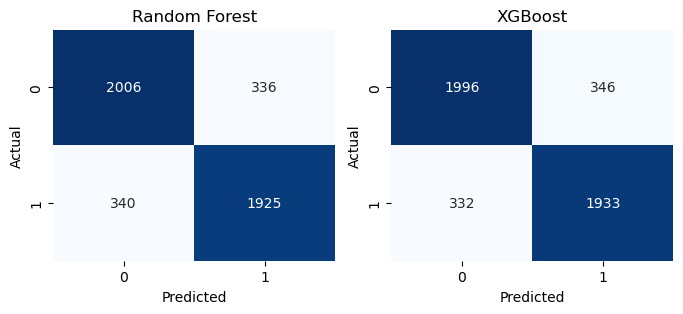

<Figure size 400x300 with 0 Axes>

<Figure size 400x300 with 0 Axes>

In [47]:
from sklearn.metrics import confusion_matrix


# Create a function to plot confusion matrix
def plot_confusion_matrix(ax, y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d',cmap='Blues', cbar=False,ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
# Plotting
plot_confusion_matrix(axes[0],y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(axes[1],y_test, y_pred_xgb, "XGBoost")

plt.tight_layout()
plt.show()

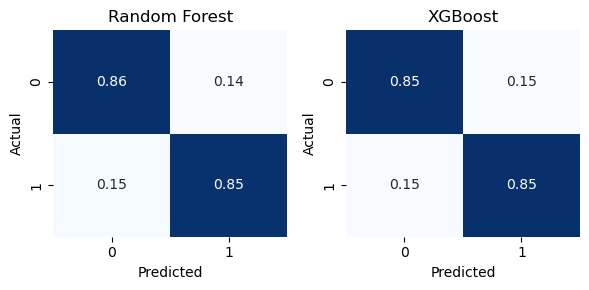

In [48]:


# Custom plot function with axes
def plot_confusion_matrix(ax, y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred, normalize='true')  # normalize to show percentages
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Create 1 row, 2 columns of plots
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Plot on subplots
plot_confusion_matrix(axes[0], y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(axes[1], y_test, y_pred_xgb, "XGBoost")

# Adjust layout
plt.tight_layout()
plt.show()


## 11. Predicting

In [50]:
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [51]:
CreditScore=int(input("Enter the CreditScore         : "))
Geography=int(input("Enter the Geography           : "))
Gender=int(input("Enter the Gender              : "))
Age=int(input("Enter the Age                 : "))
Tenure=int(input("Enter the Tenure              : "))
Balance=float(input("Enter the Balance             : "))
NumOfProducts=int(input("Enter the NumOfProducts       : "))
HasCrCard=int(input("Enter the HasCrCard           : "))
IsActiveMember=int(input("Enter the IsActiveMember      : "))
EstimatedSalary=float(input("Enter the EstimatedSalary     : "))

pre=np.array([CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary])
pre

Enter the CreditScore         :  608
Enter the Geography           :  2
Enter the Gender              :  0
Enter the Age                 :  41
Enter the Tenure              :  1
Enter the Balance             :  83807.86
Enter the NumOfProducts       :  1
Enter the HasCrCard           :  0
Enter the IsActiveMember      :  1
Enter the EstimatedSalary     :  112542.58


array([6.0800000e+02, 2.0000000e+00, 0.0000000e+00, 4.1000000e+01,
       1.0000000e+00, 8.3807860e+04, 1.0000000e+00, 0.0000000e+00,
       1.0000000e+00, 1.1254258e+05])

Predicted value:-  [0]


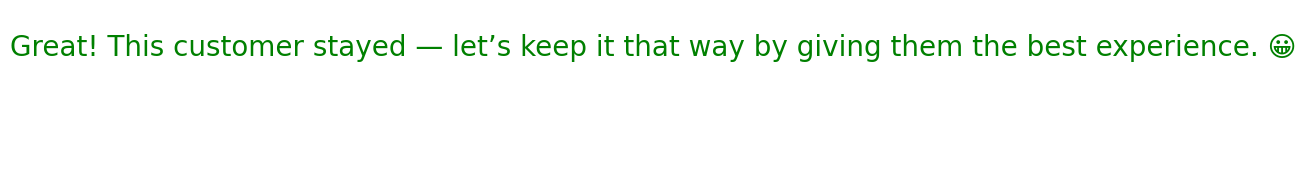

In [94]:
import emoji

Predict=model_rf.predict([pre]) 
print("Predicted value:- ",Predict)
if Predict==1:
    plt.figure(figsize=(3,2))
    plt.text(1.0, 0.7,emoji.emojize("Oh no! One customer is already gone. If we don’t fix the problem, more will follow! :tired_face:"),  fontsize=20, ha='center', color='red')
    plt.axis('off')
    plt.show()
    
else:
    plt.figure(figsize=(3,2))
    plt.text(1.0, 0.7, emoji.emojize("Great! This customer stayed — let’s keep it that way by giving them the best experience. :grinning_face:"), fontsize=20, ha='center', color='green')
    plt.axis('off')
    plt.show()

###### 